In [1]:
import osmnx as ox
import networkx as nx

In [7]:
CU = ox.geocode_to_gdf(['Champaign, Illinois, USA', 'Urbana, Illinois, USA'])

In [8]:
places = [
    "Champaign, Illinois, USA",
    "Urbana, Illinois, USA"
]
gdf = ox.geocode_to_gdf(places)

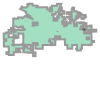

In [9]:
gdf.unary_union

In [10]:
G1 = ox.graph_from_polygon(gdf['geometry'][1], network_type="walk")
G0 = ox.graph_from_polygon(gdf['geometry'][0], network_type="walk")

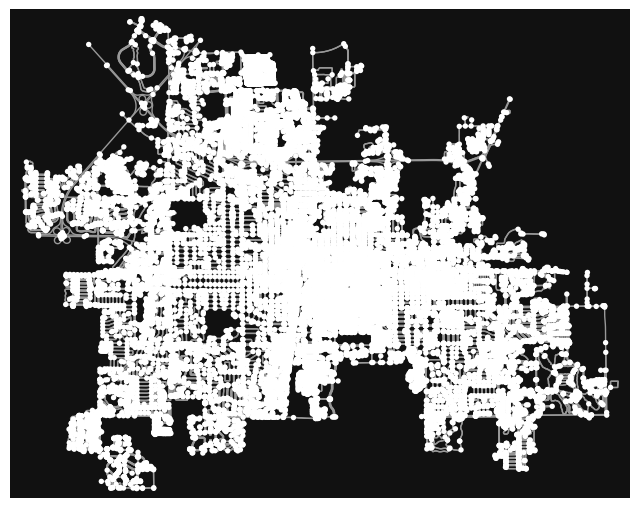

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [11]:
ox.plot_graph(ox.graph_from_polygon(gdf.unary_union))

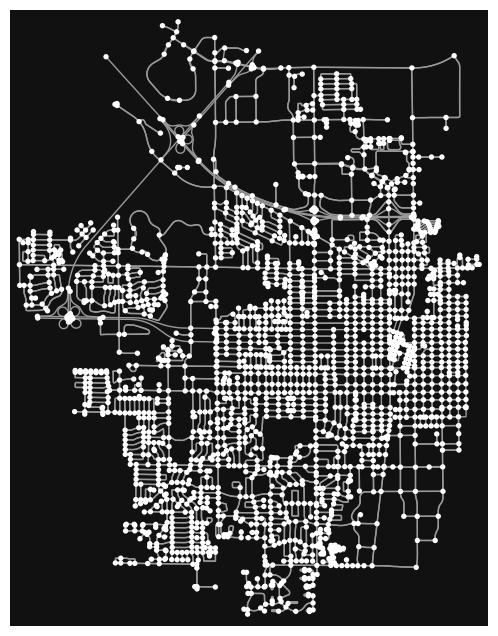

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [1]:
import osmnx as ox

champaign = ox.graph_from_place('Champaign, IL, USA', network_type='drive')



In [2]:
import json

'''nodes = champaign.nodes

for i,node in enumerate(nodes):
    if not i:
        print(node)
        views = [view for view in champaign[node].values()]
        for view in views:
            print(view[0]['name'])'''

edges = champaign.edges

for i, edge in enumerate(edges):
    if not i:
        print(edge)
        print(champaign[edge[0]][edge[1]])
        #print(champaign[edge[1]])

(37945137, 38032634, 0)
{0: {'osmid': 237756215, 'oneway': True, 'name': 'West University Avenue', 'highway': 'primary', 'maxspeed': '30 mph', 'reversed': False, 'length': 141.592}}


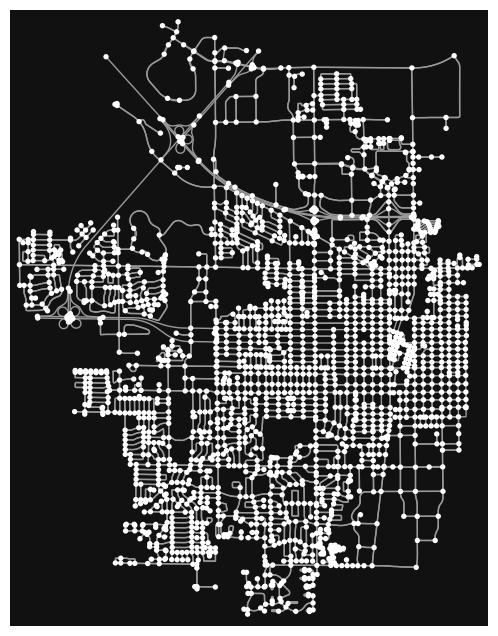

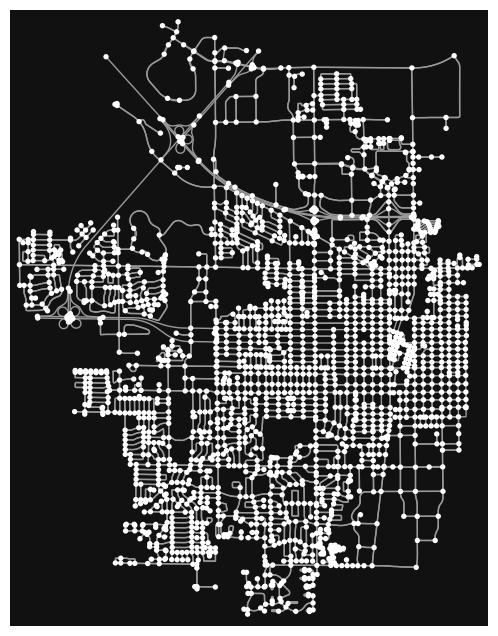

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [1]:
import os
import sys
import osmnx as ox
import networkx as nx
import numpy as np

champaign = ox.graph_from_place('Champaign, IL, USA', network_type='drive')
champaign = ox.speed.add_edge_speeds(champaign)
champaign = ox.speed.add_edge_travel_times(champaign)

travel_times_dict = nx.get_edge_attributes(champaign, 'travel_time')

indexes = {node: i for i, node in enumerate(champaign.nodes)}

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)



ox.plot_graph(champaign)

from utils import node_from_address

starting_node = node_from_address(champaign, '1008 S 4th Street, Champaign, IL')
final_node = node_from_address(champaign, '2610 N Prospect Ave, Champaign, IL')

ox.plot_graph(champaign)

442.70000000000005


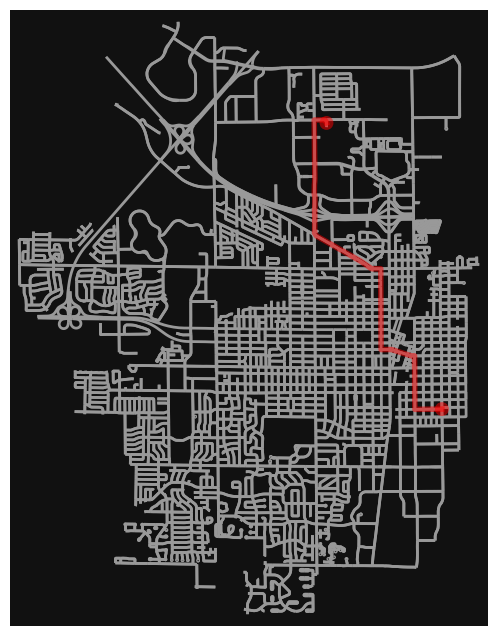

In [5]:
import gurobipy as gp
from gurobipy import GRB

edges = list(champaign.edges)

banned_coords = [(40.130902, -88.243662), (40.130462, -88.238855), (40.132660, -88.243546)]

banned_nodes = [ox.nearest_nodes(champaign, lon, lat) for lat, lon in banned_coords]

banned_nodes = []

#edge_idx = [i for i, edge in enumerate(edges) if edge == (37982929, 37982924, 0)]

#print(edge_idx)

n_points = len(champaign.nodes)
n_edges = len(champaign.edges)

A = np.zeros((n_points, n_edges))



for i, (u, v, k) in enumerate(edges):
    if u in banned_nodes or v in banned_nodes:
        print(u, v)
        continue

    A[indexes[u]][i] = -1
    A[indexes[v]][i] = 1

#print(sum(A[edge_idx[0]]))

#A[edge_idx[0]] = np.zeros(n_edges)

#print(sum(A[edge_idx[0]]))


b = np.zeros(n_points)

b[indexes[starting_node]] = -1
b[indexes[final_node]] = 1

f = np.zeros(n_edges)

m = gp.Model("lp")

m.Params.LogToConsole = 0
m.Params.Method = 0

f = m.addMVar(shape=n_edges, vtype=GRB.CONTINUOUS, lb=0, name="")

weights = [travel_time for edge, travel_time in travel_times_dict.items()]

m.addConstr(A@f==b)
#m.addConstr(f[edge_idx] == 0)
obj = np.array(weights)@f
m.setObjective(obj, GRB.MINIMIZE)
m.optimize()

print(m.ObjVal)

flows = m.getAttr("X", m.getVars())

flowed_edges_idx = []
flowed_edges = []

for i in range(len(flows)):
        if flows[i]:
            flowed_edges_idx += [i]

flowed_pts = []

for i, (u, v, k) in enumerate(champaign.edges):
    if i in flowed_edges_idx:
        flowed_edges += [(u, v)]

        for pt in (u, v):
            if pt not in flowed_pts:
                flowed_pts += [pt]




current_edge = [edge for edge in flowed_edges if edge[0] == starting_node][0]

route_edges = [current_edge]
route_pts = [current_edge[0]]

flowed_edges.remove(current_edge)

while len(flowed_edges):
    for edge in flowed_edges:
        #print(edge, current_edge)
        if current_edge[1] == edge[0]:
            route_edges += [edge]
            route_pts += [edge[0]]
            flowed_edges.remove(edge)
            current_edge = edge
            continue

fig, ax = ox.plot_graph_route(champaign, route_pts, node_color='w', node_edgecolor='k', node_size=0, 
                           node_zorder=3, edge_linewidth=2)

#print(list(champaign.nodes)[edge_idx[0]] in flowed_pts)

In [123]:
travel_times_dict

{(37945137, 38032634, 0): 10.6,
 (37945137, 37945139, 0): 8.4,
 (37945137, 38033571, 0): 7.5,
 (37945139, 37945140, 0): 8.0,
 (37945139, 38162699, 0): 13.8,
 (37945139, 38032644, 0): 10.5,
 (37945139, 37945137, 0): 8.4,
 (37945140, 37945139, 0): 8.0,
 (37945140, 37945142, 0): 14.8,
 (37945140, 38124038, 0): 7.5,
 (37945142, 37945145, 0): 9.9,
 (37945142, 37945140, 0): 14.8,
 (37945142, 37997572, 0): 7.5,
 (37945142, 37997564, 0): 6.4,
 (37945145, 37945147, 0): 2.7,
 (37945145, 37945142, 0): 9.9,
 (37945145, 37997574, 0): 16.2,
 (37945145, 38003978, 0): 6.3,
 (37945147, 37945145, 0): 2.7,
 (37945237, 37945255, 0): 11.2,
 (37945237, 38035745, 0): 8.2,
 (37945237, 38035721, 0): 6.9,
 (37945255, 37945265, 0): 7.5,
 (37945255, 37945237, 0): 11.2,
 (37945255, 37961924, 0): 2.1,
 (37945265, 37945269, 0): 2.9,
 (37945265, 37945255, 0): 7.5,
 (37945265, 38013619, 0): 4.5,
 (37945269, 37945271, 0): 3.5,
 (37945269, 37945265, 0): 2.9,
 (37945269, 38035745, 0): 19.9,
 (37945271, 37945273, 0): 7.5,

In [75]:
coords = node_from_address(champaign,'736 N Market St, Champaign, IL')

TypeError: nearest_nodes() missing 2 required positional arguments: 'X' and 'Y'

In [79]:
ox.nearest_nodes(champaign, -88.239839, 40.121090)

38035359

In [12]:

i0 = list(champaign.nodes)[0]
indexes[i0], champaign[i0]
indexes[38032634]

edges = list(champaign.edges)



A

array([[-1., -1., -1., ...,  0.,  0.,  0.],
       [ 0.,  1.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  1.,  1.,  0.],
       [ 0.,  0.,  0., ..., -1., -1.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0., -1.]])

In [44]:
champaign[7413868600][7413868599]

AtlasView({0: {'osmid': 792842156, 'name': 'North Clock Street', 'highway': 'residential', 'oneway': False, 'reversed': True, 'length': 91.995, 'geometry': <LINESTRING (-88.237 40.13, -88.237 40.13, -88.237 40.13)>}, 1: {'osmid': [1085340151, 792842155, 792842159], 'name': ['Posey Street', 'Bellefontaine Street', 'East Roper Street'], 'highway': 'residential', 'oneway': False, 'reversed': True, 'length': 240.619, 'geometry': <LINESTRING (-88.237 40.13, -88.236 40.13, -88.236 40.13, -88.236 40.13, -88...>}})

True
41


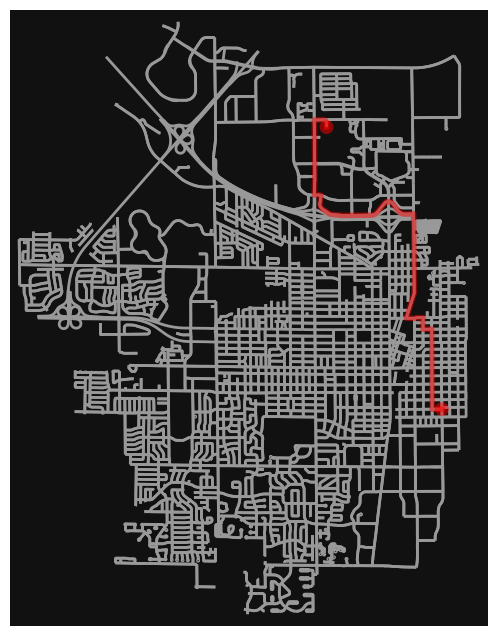

In [57]:
print(nx.has_path(nx.DiGraph(champaign), starting_node, final_node))

route = nx.shortest_path(champaign, starting_node, final_node)

flowed_edges = []

route_length = len(route)
print(route_length)

for i in range(route_length-1):
    flowed_edges += [(route[i], route[i+1])]

fig, ax = ox.plot_graph_route(champaign, route, node_color='w', node_edgecolor='k', node_size=0, 
                           node_zorder=3, edge_linewidth=2)

for node in nodes:
    info = champaign[node]
    s_4th = 0
    e_arm = 0
    for connecting_node in info:
        if not 'name' in champaign[node][connecting_node][0]:
            continue #== 'South Fourth Street':
        if champaign[node][connecting_node][0]['name'] == 'South Fourth Street' :
            s_4th = 1
        if champaign[node][connecting_node][0]['name'] == 'East Armory Avenue':
            e_arm = 1
        if s_4th + e_arm >= 2:
            print(champaign[node])
            #print(champaign[node], champaign[connecting_node])
        #print(1)